In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('D:\sprints project\selected_data.csv')
df.head()

,PC4,PC5,PC2,PC1,PC8,PC3,PC9,PC7,PC6,PC10,Target
0,2.293052,0.023175,-1.087655,1.130664,-0.536787,3.164263,-1.495392,0.664854,0.578814,-0.499485,0
1,-0.857970,-0.006289,-1.417885,3.190926,1.069777,-0.533715,0.342524,-0.259063,0.745347,1.431509,1
2,-0.626641,0.152793,0.657008,3.124339,0.209299,-0.285134,0.043205,-0.324995,1.130179,0.462304,1
3,2.832741,0.721309,1.410972,-0.484339,-2.153525,0.397806,0.760079,-0.522221,-0.388361,0.228379,0
4,1.209318,0.770835,-0.330033,-2.284542,0.014736,-0.072260,1.050381,0.379567,0.625587,0.628110,0


### 1. Apply K-Means Clustering (Elbow Method to determine K)

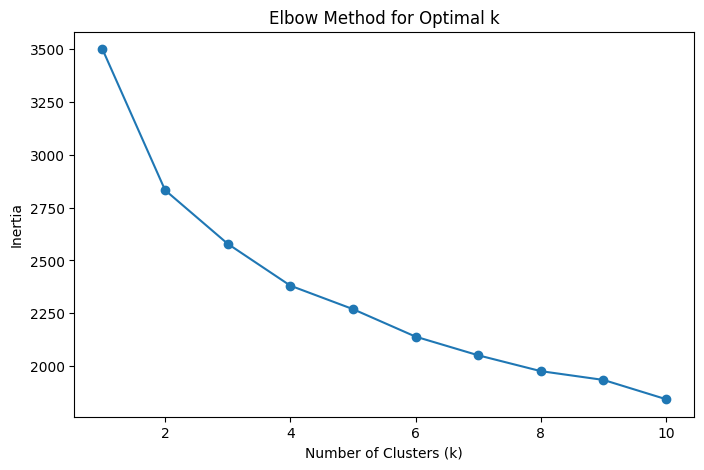

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow Method
inertia = []
K_range = range(1, 11)

X = df.drop(columns=['Target'])
y = df['Target']
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)  
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

### 2. Perform Hierarchical Clustering (Dendrogram Analysis)

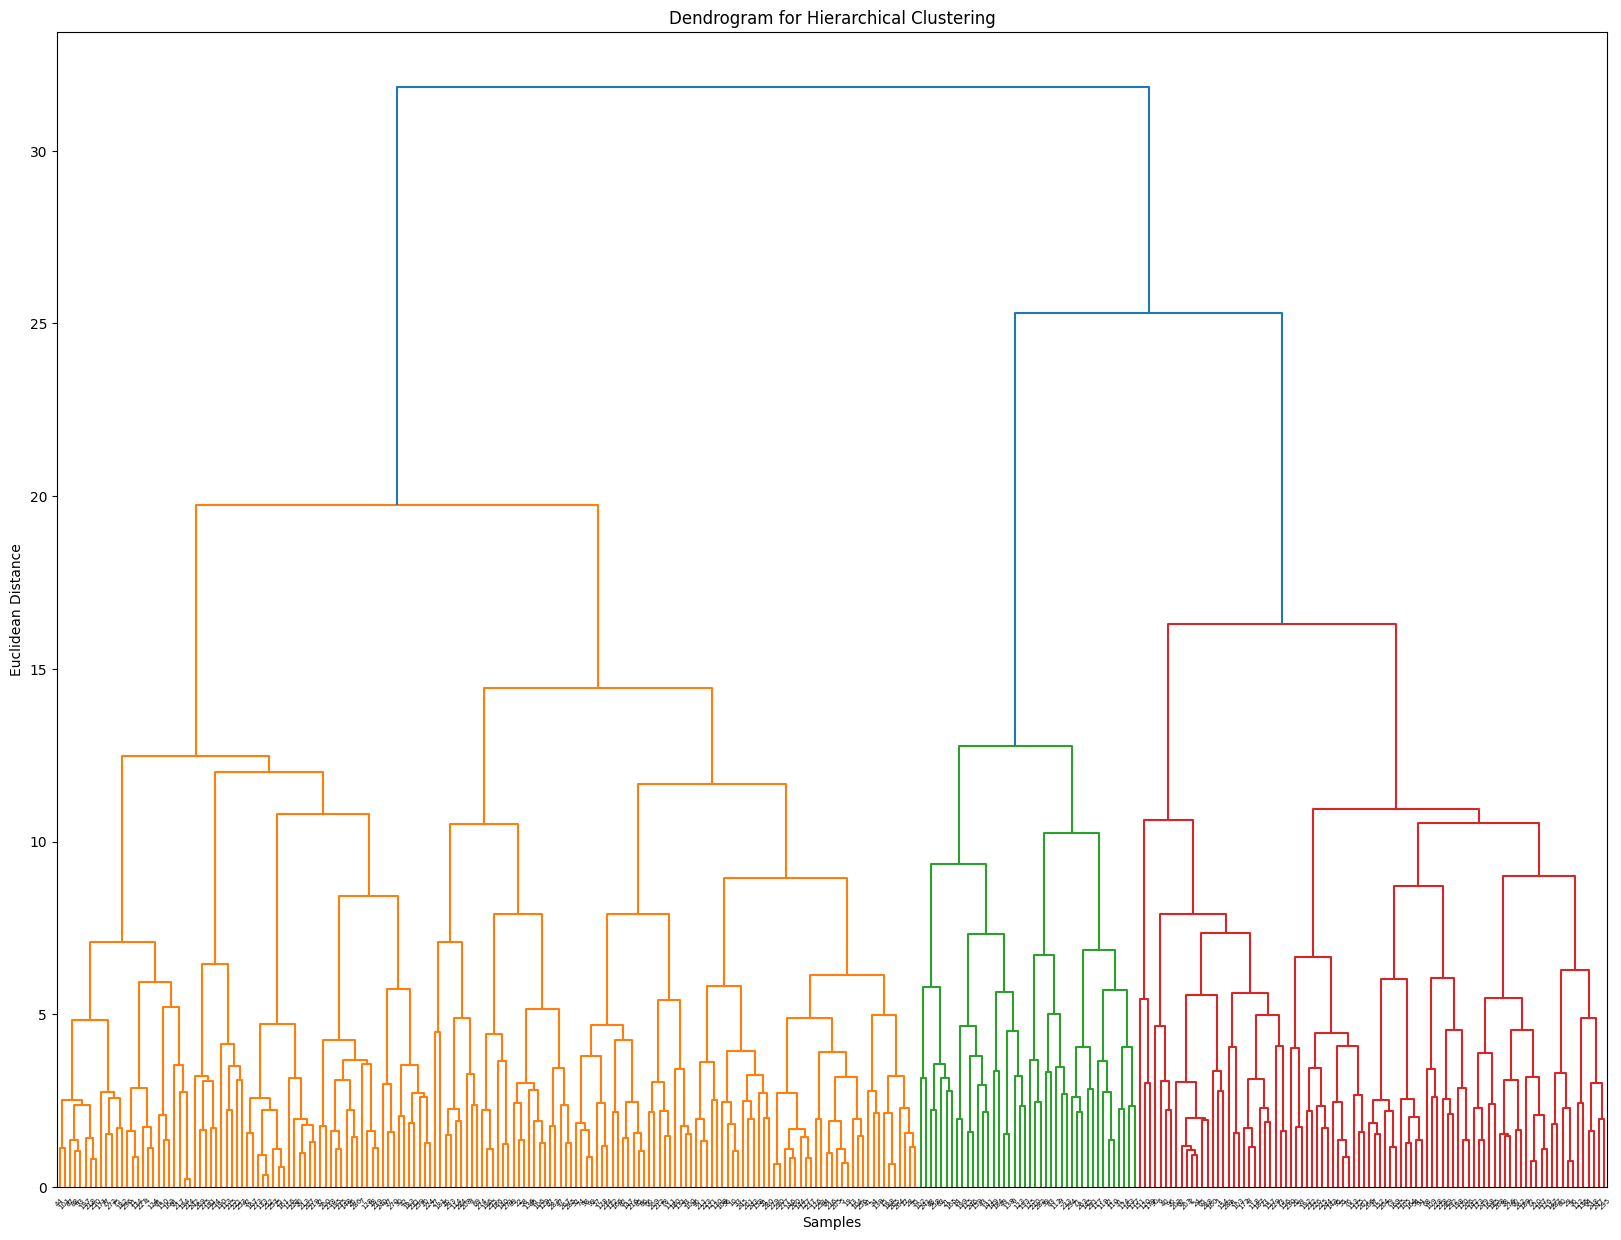

In [9]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(20, 15))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.xticks(rotation= 45)
plt.ylabel("Euclidean Distance")
plt.show()

### 3. Fit Models and Compare with Actual Labels

In [10]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Fit KMeans with chosen K 
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc.fit_predict(X)

# Compare with actual labels
print("KMeans ARI:", adjusted_rand_score(y, kmeans_labels))
print("Hierarchical ARI:", adjusted_rand_score(y, hc_labels))

# Optional: silhouette score (higher is better, -1 to 1)
print("KMeans Silhouette Score:", silhouette_score(X, kmeans_labels))
print("Hierarchical Silhouette Score:", silhouette_score(X, hc_labels))

KMeans ARI: 0.4379944036207641
Hierarchical ARI: 0.24240623078499693
KMeans Silhouette Score: 0.19210296059446424
Hierarchical Silhouette Score: 0.15460591351405184


### 4. Visualize Clusters

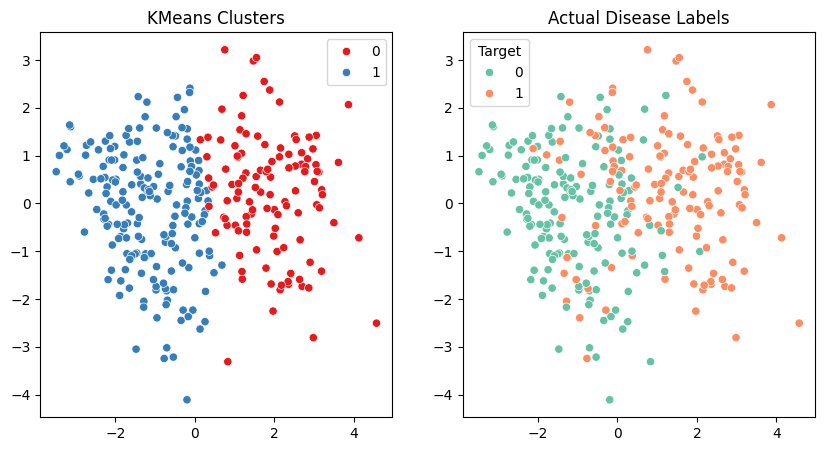

In [11]:
import seaborn as sns
import pandas as pd

df_cluster = pd.DataFrame(X, columns=X.columns)
df_cluster['KMeans Cluster'] = kmeans_labels
df_cluster['Actual Disease'] = y.values

# Scatter plot using first 2 PCA components for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette="Set1")
plt.title("KMeans Clusters")

plt.subplot(1,2,2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set2")
plt.title("Actual Disease Labels")

plt.show()
